# 06 — Learning Point Spread Function (PSF) models for atmospheric correction

This notebook focuses on the determination of atmospheric Point Spread Functions used in atmospheric correction. The atmospheric correction aims to determine the surface reflectance $\rho_s$ from the reflectance measured by the satellite e.g. TOA reflectance $\rho_{toa}$. The most commonly used model for atmospheric reflection is the 5S model : 

$$
    \rho_{toa} = \rho_{atm} + T^\downarrow \frac{
        T_{dir}^\uparrow \rho_s + T_{dif}^\uparrow \rho_s \ast P_{5S}
    }{
        1 - s \rho_s \ast P_{5S}
    }
$$

where $P_{5S}$ is the 5S PSF. This PSF is quite difficult to determine because it depends on both the scattering in the atmosphere and the coupling effects between the ground in the atmosphere. It is not possible to determine this PSF directly because coupling effects depend on the ground reflectance. A solution lies in using a Monte-Carlo model to simulate $\rho_{toa}(i,j)$ for different input surface reflectance maps $\rho_s(i,j)$, and then find a $P_{5S}$ model that can explain with the best possible accuracy the link between all the maps.

Another model (AMARTIS) decouples purely atmospheric effects from coupling effects :

$$
    \rho_{toa} = \rho_{atm} + T^\downarrow \frac{
        T_{dir}^\uparrow \rho_s + T_{dif}^\uparrow \rho_s \ast P_{atm}
    }{
        1 - s \rho_s \ast P_{coupling}
    }
$$

where $P_{atm}$ is the PSF of pure atmospheric scattering on the way back to the sensor, and $P_{coupling}$ the PSF of coupling effects between the ground and the atmosphere. The determination of $P_{coupling}$ is based on the same methodology as for $P_{5S}$, but is not implemented yet in the library. The determination of $P_{atm}$ is simpler, as it can be directly sampled by a Monte-Carlo simulation, launching photons from the sensor in a fixed direction and collecting the flux on the ground with a sampling grid.

This notebook illustrates two approaches to obtain the atmospheric PSF:

| Approach | Method | Tool |
|---|---|---|
| **Atm PSF** | Smart-G Monte-Carlo simulation (Entity) | `sample_psf_atm` |
| **5S King PSF** | Inverse optimisation on synthetic scenes | `optimize_adam_lbfgs` |

A final figure compares the radial profiles of both PSFs.

**Requires:** `SMARTG_DIR_AUXDATA` set and a CUDA GPU.

In [1]:
import os
import structlog
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from adjeff.api import make_full_config, run_forward_pipeline, make_model, optimize_adam_lbfgs, sample_psf_atm
from adjeff.core import S2Band, gaussian_image_dict
from adjeff.modules.models import Unif2Surface
from adjeff.core import KingPSF
from adjeff.optim import Loss, TrainingImages
from adjeff.optim.adam_optimizer import AdamConfig
from adjeff.optim.lbfgs_optimizer import LBFGSConfig
from adjeff.optim.metrics import Metric
from adjeff.utils import CacheStore

assert "SMARTG_DIR_AUXDATA" in os.environ, (
    "Set SMARTG_DIR_AUXDATA to the Smart-G auxiliary data directory."
)

structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## Shared configuration

Parameters shared between both parts.

| Parameter | Value | Description |
|---|---|---|
| `BAND` | B03 (560 nm) | Sentinel-2 green band |
| `RES_KM` | 0.12 km | Native Sentinel-2 resolution (120 m) |
| `N` | 1999 | Grid size — the scene extends over ~120 km radius |
| `AOT` | 0.4 | Aerosol optical thickness |
| `rh` | 50 % | Relative humidity |
| `sza / vza` | 30° / 10° | Sun and view zenith angles |

`make_full_config` assembles an `AtmoConfig`, a `GeoConfig` and a `SpectralConfig` from these scalars. Both parts then draw from this shared config so that their results are directly comparable.

In [2]:
BAND     = S2Band.B03   # 560 nm
RES_KM   = 0.12         # résolution 120 m
N        = 1999          # grille 201×201 → étendue ~24 km
AOT_VALUES = [0.4]

cfg = make_full_config(
    bands=[BAND],
    aot=AOT_VALUES,
    rh=50.0,
    h=0.0,
    href=2.0,
    sza=30.0,
    vza=10.0,
    saa=120.0,
    vaa=120.0,
)

cache = CacheStore("./adjeff_cache")

---
## Part 1 — Atmospheric PSF (Smart-G Entity)

Smart-G is a GPU-accelerated Monte-Carlo radiative transfer code. In this mode, photons are launched in back-propagation from the sensor in a fixed direction and their flux is recorded on the ground with a sampling grid called an *Entity*. The normalized energy map on that grid is the atmospheric PSF $P_{atm}$ — it directly quantifies how much a surface pixel at distance $r$ from the nominal line of sight contributes to the measured radiance.

This approach works because $P_{atm}$ only involves atmospheric scattering and does not depend on the surface. It can therefore be sampled independently of the scene, which makes it cheap to compute and exact within Monte-Carlo noise.

### 1.1 — Sampling

`sample_psf_atm` calls Smart-G with an Entity grid of size `N × N` and resolution `res_km`.  
`n_ph=1e8` photons are used to keep Monte-Carlo noise low in the PSF tails, where the signal is very small. Setting `remove_rayleigh=False` retains the full atmospheric scattering (aerosol + Rayleigh). Results are cached on disk so the simulation is not re-run on subsequent calls.

In [3]:
psf_dict_atm = sample_psf_atm(
    bands=[BAND],
    res_km=RES_KM,
    n=N,
    atmo_config=cfg["atmo_config"],
    geo_config=cfg["geo_config"],
    remove_rayleigh=False,
    n_ph=int(1e8),
    cache=cache,
)
print(psf_dict_atm)

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:1124: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : incompatible redefinition for option 'compiler-bindir', the last value of this option was used

  self.mod = SourceModule(


Box(children=(FloatProgress(value=0.0, max=100000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
PSFDict(bands=[S2Band.B03], vars={S2Band.B03: [kernel]})


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### 1.2 — Kernel inspection

The output is a `PSFDict` wrapping a multi-dimensional `DataArray`. All atmospheric parameters (`aot`, `rh`, `href`, `h`, `vza`, `vaa`) become named coordinates, even when scalar. This layout makes later `.sel()` calls unambiguous and allows the PSF to be extended to parameter sweeps without changing the downstream code.

In [4]:
kernel_atm = psf_dict_atm.kernel(BAND)
print("Dimensions du kernel atm :", kernel_atm.dims)
print(kernel_atm)

Dimensions du kernel atm : ('href', 'h', 'rh', 'aot', 'vaa', 'vza', 'x', 'y')
<xarray.DataArray 'kernel' (href: 1, h: 1, rh: 1, aot: 1, vaa: 1, vza: 1,
                            x: 1999, y: 1999)> Size: 32MB
array([[[[[[[[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00],
             [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00],
             [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00],
             ...,
             [0.00000e+00, 3.21194e-08, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00],
             [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00],
             [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00, 0.00000e+00]]]]]]]], shape=(1, 1, 1, 1, 1, 1, 1999, 1999))
Coordinates:
  * href        (href) float64 8B 2.0
  * h           (h) float64 8B 0.0
  * rh          (rh) float64 8B 50.0
  * aot         

### 1.3 — Radial profile per AOT

The 2D kernel is collapsed to a 1D radial profile using the `.adjeff.radial()` accessor, which bins pixels by distance from the centre and averages their values. The log-scale y-axis is important: the PSF spans several orders of magnitude and the tail behaviour (large $r$) is precisely what drives adjacency effects over distant pixels.

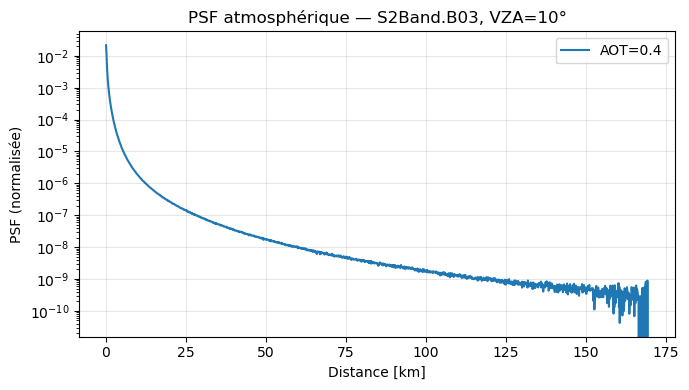

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

for aot_val in AOT_VALUES:
    # Sélectionner le kernel pour cet AOT et squeeze toutes les dims scalaires
    k = (
        kernel_atm
        .sel(aot=aot_val, method="nearest")
        .squeeze()
    )
    profile = k.adjeff.radial()
    ax.plot(profile.coords["r"].values, profile.values, label=f"AOT={aot_val}")

ax.set_xlabel("Distance [km]")
ax.set_ylabel("PSF (normalisée)")
ax.set_yscale("log")
ax.set_title(f"PSF atmosphérique — {BAND}, VZA=10°")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2 — 5S King PSF (inverse optimisation)

Unlike $P_{atm}$, the 5S PSF $P_{5S}$ cannot be sampled directly: it mixes atmospheric scattering with ground–atmosphere coupling effects, so it is scene-dependent. The strategy is to learn it by inversion.

The forward pipeline converts a known surface map $\rho_s$ into the corresponding uniform-equivalent reflectance $\rho_{unif}$ observed by the satellite:

$$\rho_s^{\text{Gaussian}} \xrightarrow{\text{Smart-G}} \rho_{toa} \xrightarrow{\text{Toa2Unif}} \rho_{unif}$$

The `Unif2Surface` model then applies the 5S formula with a parametric King PSF to reconstruct $\hat\rho_s$ from $\rho_{unif}$. The optimiser adjusts the PSF parameters so that $\hat\rho_s \approx \rho_s$ across all training scenes.

### 2.1 — Training scenes

Three Gaussian surface maps with widths `sigma = [1, 5, 50] km` are generated. Using a variety of spatial scales ensures that the optimiser must reproduce the PSF shape at all radii — a single scene would only constrain the PSF at the scale of its own features.

`run_forward_pipeline` runs the full radiative chain (Smart-G TOA sampling + 5S inversion) for each scene and stores the results as `ImageDict` objects ready for training. `nr=500` is the number of radial bins used in the TOA Monte-Carlo sampling; `n_ph=1e5` is intentionally lower than in Part 1 to keep the forward simulation fast — the noise averages out across scenes during optimisation.

In [6]:
SIGMAS = [1.0, 5.0, 50.0]   # largeurs Gaussiennes [km]

raw_scenes = [
    gaussian_image_dict(
        sigma=sigma,
        res_km=RES_KM,
        rho_min=0.05,
        rho_max=0.6,
        bands=[BAND],
        n=N,
    )
    for sigma in SIGMAS
]

# Pipeline direct : rho_s → rho_toa → rho_unif (+ quantités radiatives)
train_scenes = run_forward_pipeline(
    raw_scenes,
    atmo_config=cfg["atmo_config"],
    geo_config=cfg["geo_config"],
    spectral_config=cfg["spectral_config"],
    remove_rayleigh=False,
    nr=500,
    n_ph=int(1e5),
    cache=cache,
)

train_images = TrainingImages(
    images=train_scenes,
    weights=[1.0] * len(train_scenes),
)
print(f"{len(train_images.images)} scènes d'entraînement prêtes.")

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


...

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=190000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
3 scènes d'entraînement prêtes.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### 2.2 — King PSF model

The King profile is a power-law kernel commonly used in astrophysics to model PSFs with heavy tails:

$$P_{King}(r, \sigma, \gamma) \propto \left(1 + \frac{r^2}{2\gamma\sigma^2}\right)^{-\gamma}$$

- $\sigma$ (scale radius): controls the PSF core width.
- $\gamma$ (power-law exponent): controls how fast the tails decay. Larger $\gamma$ → faster decay.

Both parameters are `ConstrainedParameter` instances, meaning they are stored as unconstrained tensors internally and mapped to physically valid ranges via a smooth transform. This avoids gradient issues at the boundaries during optimisation.

In [7]:
model = make_model(
    Unif2Surface,
    KingPSF,
    bands=[BAND],
    res_km=RES_KM,
    n=N,
    init_parameters={"sigma": 1.0, "gamma": 2.0},
    device="cuda",
)
print(model)

Unif2Surface(
  (_psfs): ModuleDict(
    (B03): KingPSF(
      (sigma): ConstrainedParameter()
      (gamma): ConstrainedParameter()
    )
  )
)


### 2.3 — Optimisation (Adam warm-up + L-BFGS)

The two-phase schedule is motivated by their complementary strengths:

- **Adam warm-up** (stochastic first-order): robust to poor initialisation, escapes local minima and quickly moves the parameters into a reasonable basin.
- **L-BFGS** (quasi-Newton second-order): exploits curvature information for fast, precise convergence once in the right region.

The loss `RMSE_RAD` is the radially-weighted root mean squared error. Radial weighting gives more importance to distant pixels — exactly where adjacency effects concentrate — and prevents the optimiser from over-focusing on the bright PSF core at the expense of the tails.

In [8]:
psf_dict_king = optimize_adam_lbfgs(
    model=model,
    train_images=train_images,
    loss=Loss(metric=Metric.RMSE_RAD),
    adam_config=AdamConfig(
        min_steps=5,
        max_steps=20,
        loss_relative_tolerance=1e-4,
        loss=Loss(metric=Metric.RMSE_RAD),
    ),
    lbfgs_config=LBFGSConfig(
        min_steps=5,
        max_steps=30,
        loss_relative_tolerance=1e-6,
        loss=Loss(metric=Metric.RMSE_RAD),
    ),
    device="cuda",
)
print(psf_dict_king)


PSFDict(bands=[S2Band.B03], vars={S2Band.B03: [kernel, param_gamma, param_sigma]})


### 2.4 — Learned radial profile

The kernel returned by the optimiser uses `x_psf / y_psf` dimension names (to distinguish it from scene data). The `.adjeff.radial()` accessor handles both `x/y` and `x_psf/y_psf` automatically.

King kernel dimensions: ('sza', 'vza', 'h', 'href', 'rh', 'aot', 'y_psf', 'x_psf')


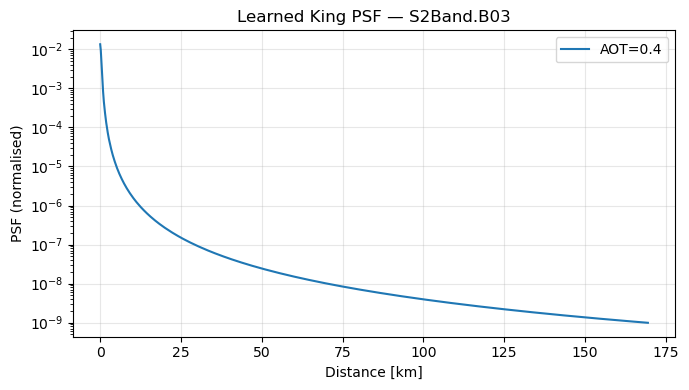

In [9]:
kernel_king = psf_dict_king.kernel(BAND)
print("King kernel dimensions:", kernel_king.dims)

fig, ax = plt.subplots(figsize=(7, 4))
for aot_val in AOT_VALUES:
    k = kernel_king.sel(aot=aot_val, method="nearest").squeeze()
    profile = k.adjeff.radial()
    ax.plot(profile.coords["r"].values, profile.values, label=f"AOT={aot_val}")

ax.set_xlabel("Distance [km]")
ax.set_ylabel("PSF (normalised)")
ax.set_yscale("log")
ax.set_title(f"Learned King PSF — {BAND}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Comparison: Atm PSF vs King PSF

Radial profile overlay for each AOT value. Solid lines are the Monte-Carlo reference ($P_{atm}$); dashed lines are the learned King PSF ($P_{5S}$).

If the optimisation has converged, both profiles should align closely. Residual discrepancies can reveal:
- **Core mismatch**: the King model may be too rigid to capture the exact core shape.
- **Tail mismatch**: insufficient training data at large scales, or Monte-Carlo noise dominating the reference at large $r$.
- **Systematic offset**: a sign that $P_{atm}$ and $P_{5S}$ are fundamentally different objects — which is expected, since $P_{5S}$ also absorbs coupling effects.

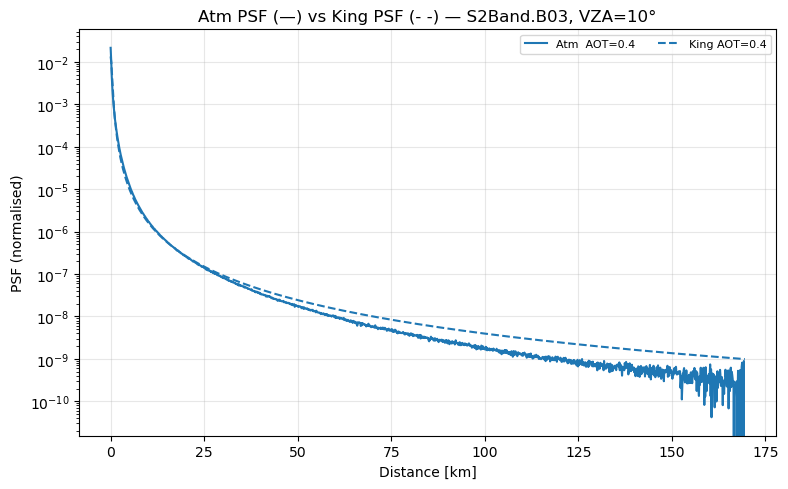

In [11]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5))

for i, aot_val in enumerate(AOT_VALUES):
    color = colors[i % len(colors)]

    # Atm PSF
    k_atm = kernel_atm.sel(aot=aot_val, method="nearest").squeeze()
    p_atm = k_atm.adjeff.radial()
    ax.plot(
        p_atm.coords["r"].values, p_atm.values,
        color=color, linestyle="-",
        label=f"Atm  AOT={aot_val}",
    )

    # King PSF
    k_king = kernel_king.sel(aot=aot_val, method="nearest").squeeze()
    p_king = k_king.adjeff.radial()
    ax.plot(
        p_king.coords["r"].values, p_king.values,
        color=color, linestyle="--",
        label=f"King AOT={aot_val}",
    )

ax.set_xlabel("Distance [km]")
ax.set_ylabel("PSF (normalised)")
ax.set_yscale("log")
ax.set_title(f"Atm PSF (—) vs King PSF (- -) — {BAND}, VZA=10°")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()